In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Malgun Gothic'   # 맑은 고딕
mpl.rcParams['axes.unicode_minus'] = False      # 마이너스 깨짐 방지

In [2]:
import torch
from torchviz import make_dot
import numpy as np

#### 3.5 데이터 전처리

다섯명의 신장과 체중 데이터를 사용한다.
1차 함수를 사용해 신장으로 체중을 예측하는 경우, 최적 직선을 구하는 것이 목적이다.

In [6]:
# 샘플 데이터 선언
sampleData1 = np.array([
    [166, 58.7],
    [176.0, 75.7],
    [171.0, 62.1],
    [173.0, 70.4],
    [169.0,60.1]
])
print(sampleData1)

# 머신러닝 모델에서 사용하기 위해, 신장을 변수 x로,
# 체중을 변수 y로 함

x = sampleData1[:,0]
y = sampleData1[:,1]

[[166.   58.7]
 [176.   75.7]
 [171.   62.1]
 [173.   70.4]
 [169.   60.1]]


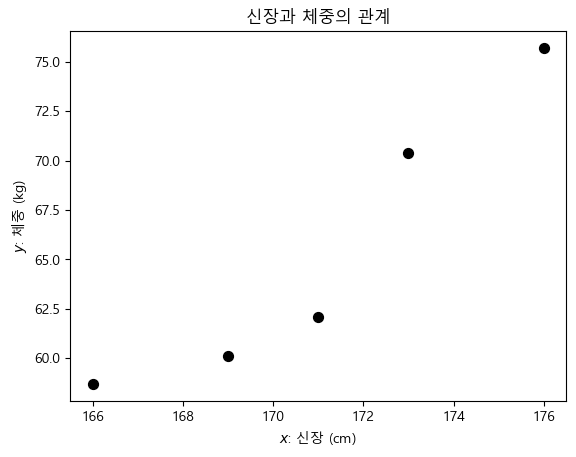

In [7]:
# 산포도 출력 확인

plt.scatter(x,  y,  c='k',  s=50)
plt.xlabel('$x$: 신장 (cm) ')
plt.ylabel('$y$: 체중 (kg)')
plt.title('신장과 체중의 관계')
plt.show()

#### 데이터 변환
머신러닝 모델에서 데이터는 0에 가까운 값을 갖는 것이 바람직하다. 따라서, x, y 모두 평균값이 0이 되도록 평행이동시켜서 새로운 좌표계를 X, Y로 한다.

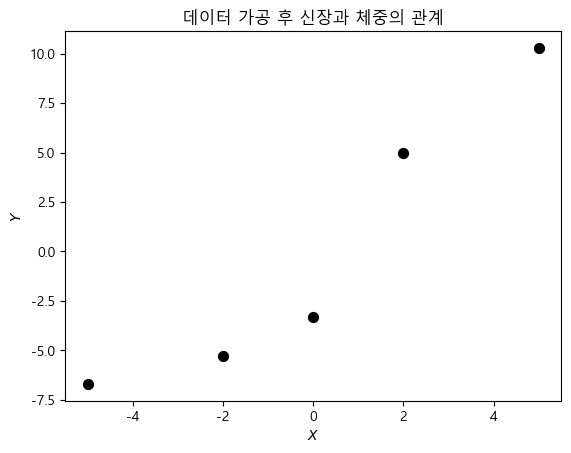

In [ ]:
X = x - x.mean()
Y = y - y.mean()


# 산포도를 통해 결과 확인
plt.scatter(X,  Y,  c='k',  s=50)
plt.xlabel('$X$')
plt.ylabel('$Y$')
plt.title('데이터 가공 후 신장과 체중의 관계')
plt.show()

#### 3.6 예측 계산

In [9]:
# X와 Y를 텐서 변수로 변환

X = torch.tensor(X).float()
Y = torch.tensor(Y).float()

# 결과 확인
print(X)
print(Y)

tensor([-5.,  5.,  0.,  2., -2.])
tensor([-6.7000, 10.3000, -3.3000,  5.0000, -5.3000])


In [ ]:
# 파라미터 정의
# W와 B는 경사하강법 대상; 경사 계산을 위해, requires_grad=True 로 설정함

W = torch.tensor(1.0, requires_grad=True).float()
B = torch.tensor(1.0, requires_grad=True).float()

In [11]:
# 예측 함수는 1차 함수
def pred(X):
    return W * X + B

# 예측 값 계산
Yp =  pred(X)

# 결과 확인
print(Yp)

tensor([-4.,  6.,  1.,  3., -1.], grad_fn=<AddBackward0>)


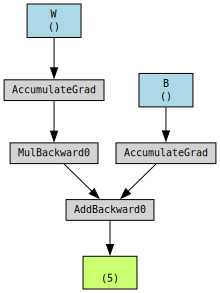

In [12]:
# 예측 값의 계산 그래프 표시

params = {'W': W, 'B': B}
g = make_dot(Yp, params=params)
display(g)

#### 3.7 손실 계산

$$ \mathrm{MSE}=\frac{1}{n}\sum_{i=1}^{n}(Y_i - Yp_i)^2 $$

In [13]:
# 평균 제곱 오차 손실함수
def mse(Yp, Y):
    loss = ((Yp - Y) ** 2).mean()
    return loss

# 손실 계산
loss = mse(Yp, Y)

# 결과 표시
print(loss)

tensor(13.3520, grad_fn=<MeanBackward0>)


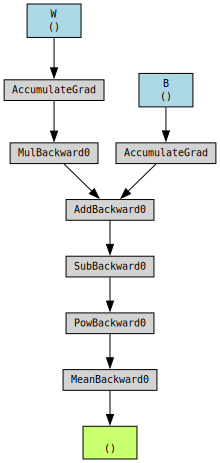

In [14]:
# 손실 계산 그래프 출력

params = {'W': W, 'B': B}
g = make_dot(loss, params=params)
display(g)

#### 3.8 경사 계산

In [15]:
# 경사 계산
loss.backward()

# 경삿값 확인
print(W.grad)
print(B.grad)


tensor(-19.0400)
tensor(2.0000)


##### 3.9 파라미터 수정

In [18]:
# 학습률 정의
lr = 0.001

#  경사를 기반으로 파라미터 수정
W -= lr * W.grad
B -= lr * B.grad

RuntimeError: a leaf Variable that requires grad is being used in an in-place operation.

W와 B는 한번 계산이 끝났기 때문에, 이 상태로 값의 갱신은 불가능하다. 따라서, 다음과 같이 수정해야 한다.

In [21]:
# 경사를 기반으로 파라미터 수정
# with torch.no_grad() 작성 필요

with torch.no_grad():
    W -= lr * W.grad
    B -= lr * B.grad
    
    # 계산이 끝난 경삿값을 초기화함
    W.grad.zero_()
    B.grad.zero_()
    
# 파라미터 경삿값 확인
print(W)
print(B)
print(W.grad)
print(B.grad)

tensor(1.0190, requires_grad=True)
tensor(0.9980, requires_grad=True)
tensor(0.)
tensor(0.)


원래 값은 모두 1.0이기 때문에, W는 미소량이 증가, B는 미소량이 감소했음을 확인할 수 있다. 이 계산을 반복해서 최적의 W와 B를 구하는 것이 경사 하강법이다.

3.12절에서 with torch.no_grad():를 사용하지 않는 방법을 소개한다. (optim과 step 함수 사용)

##### 3.10 반복 계산

In [22]:
# 초기화

# W와 B를 변수로 사용
W = torch.tensor(1.0, requires_grad=True).float()
B = torch.tensor(1.0, requires_grad=True).float()

# 반복 횟수
num_epochs = 500

# 학습률
lr = 0.001

# history 기록을 위한 배열 초기화
history = np.zeros((0, 2))

In [23]:
# 루프 처리

for epoch in range(num_epochs):

    # 예측 계산
    Yp = pred(X)
    
    # 손실 계산
    loss = mse(Yp, Y)
    
    # 경사 계산
    loss.backward()
    
    with torch.no_grad():
        # 파라미터 수정
        W -= lr * W.grad
        B -= lr * B.grad
        
        # 경삿값 초기화
        W.grad.zero_()
        B.grad.zero_()
        
    # 손실 기록
    if (epoch %10 == 0):
        item = np.array([epoch, loss.item()])
        history = np.vstack((history, item))
        print(f'epoch = {epoch}  loss = {loss:.4f}')

epoch = 0  loss = 13.3520
epoch = 10  loss = 10.3855
epoch = 20  loss = 8.5173
epoch = 30  loss = 7.3364
epoch = 40  loss = 6.5858
epoch = 50  loss = 6.1047
epoch = 60  loss = 5.7927
epoch = 70  loss = 5.5868
epoch = 80  loss = 5.4476
epoch = 90  loss = 5.3507
epoch = 100  loss = 5.2805
epoch = 110  loss = 5.2275
epoch = 120  loss = 5.1855
epoch = 130  loss = 5.1507
epoch = 140  loss = 5.1208
epoch = 150  loss = 5.0943
epoch = 160  loss = 5.0703
epoch = 170  loss = 5.0480
epoch = 180  loss = 5.0271
epoch = 190  loss = 5.0074
epoch = 200  loss = 4.9887
epoch = 210  loss = 4.9708
epoch = 220  loss = 4.9537
epoch = 230  loss = 4.9373
epoch = 240  loss = 4.9217
epoch = 250  loss = 4.9066
epoch = 260  loss = 4.8922
epoch = 270  loss = 4.8783
epoch = 280  loss = 4.8650
epoch = 290  loss = 4.8522
epoch = 300  loss = 4.8399
epoch = 310  loss = 4.8281
epoch = 320  loss = 4.8167
epoch = 330  loss = 4.8058
epoch = 340  loss = 4.7953
epoch = 350  loss = 4.7853
epoch = 360  loss = 4.7756
epoch = 37

##### 3.11 결과 평가

In [24]:
# 최종 파라미터 값
print('W = ', W.data.numpy())
print('B = ', B.data.numpy())

# 손실 확인
print(f'초기상태 : 손실:{history[0,1]:.4f}') 
print(f'최종상태 : 손실:{history[-1,1]:.4f}') 

W =  1.820683
B =  0.3675114
초기상태 : 손실:13.3520
최종상태 : 손실:4.6796


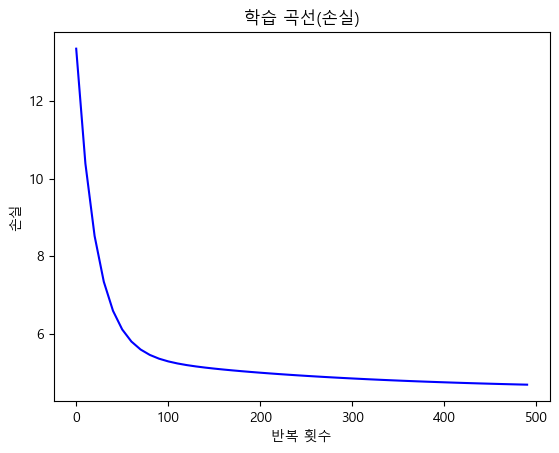

In [25]:
# 학습 곡선 출력(손실)

plt.plot(history[:,0], history[:,1], 'b')
plt.xlabel('반복 횟수')
plt.ylabel('손실')
plt.title('학습 곡선(손실)')
plt.show()

산포도에 회귀 직선을 동시에 출력함

In [26]:
# x의 범위를 구함(Xrange)
X_max = X.max()
X_min = X.min()
X_range = np.array((X_min, X_max))
X_range = torch.from_numpy(X_range).float()
print(X_range)

# 이와 대응하는 예측값 y를 구함
Y_range = pred(X_range)
print(Y_range.data)

tensor([-5.,  5.])
tensor([-8.7359,  9.4709])


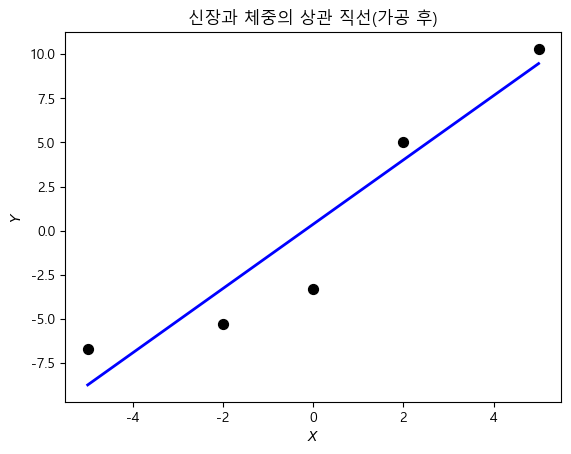

In [38]:
# 그래프 출력

plt.scatter(X,  Y,  c='k',  s=50)
plt.xlabel('$X$')
plt.ylabel('$Y$')
plt.plot(X_range.data, Y_range.data, lw=2, c='b')
plt.title('신장과 체중의 상관 직선(가공 후)')
plt.show()

가공 전 데이터로 회귀 직선 출력

In [28]:
# y좌표와 x좌표 값 계산

x_range = X_range + x.mean()
yp_range = Y_range + y.mean()

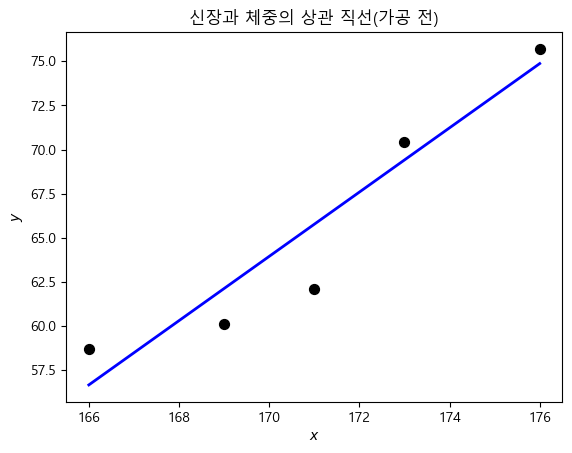

In [29]:
# 그래프 출력

plt.scatter(x,  y,  c='k',  s=50)
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.plot(x_range, yp_range.data, lw=2, c='b')
plt.title('신장과 체중의 상관 직선(가공 전)')
plt.show()

##### 3.12 최적화 함수와 step 함수 이용하기

In [30]:
# 초기화

# W와 B를 변수로 사용
W = torch.tensor(1.0, requires_grad=True).float()
B = torch.tensor(1.0, requires_grad=True).float()

# 반복 횟수
num_epochs = 500

# 학습률
lr = 0.001

# optimizer 로 SGD(확률적 경사 하강법)을 사용
import torch.optim as optim
optimizer = optim.SGD([W, B], lr=lr)

# history 기록을 위한 배열 초기화
history = np.zeros((0, 2))

In [ ]:
# 루프 처리

for epoch in range(num_epochs):

    # 예측 계산
    Yp = pred(X)
    
    # 손실 계산
    loss = mse(Yp, Y)

    # 경사 계산
    loss.backward()

    # 파라미터 수정
    optimizer.step()
    
    # 경삿값 초기화
    optimizer.zero_grad()
        
    # 손실 기록
    if (epoch %10 == 0):
        item = np.array([epoch, loss.item()])
        history = np.vstack((history, item))
        print(f'epoch = {epoch}  loss = {loss:.4f}')

epoch = 0  loss = 13.3520
epoch = 10  loss = 10.3855
epoch = 20  loss = 8.5173
epoch = 30  loss = 7.3364
epoch = 40  loss = 6.5858
epoch = 50  loss = 6.1047
epoch = 60  loss = 5.7927
epoch = 70  loss = 5.5868
epoch = 80  loss = 5.4476
epoch = 90  loss = 5.3507
epoch = 100  loss = 5.2805
epoch = 110  loss = 5.2275
epoch = 120  loss = 5.1855
epoch = 130  loss = 5.1507
epoch = 140  loss = 5.1208
epoch = 150  loss = 5.0943
epoch = 160  loss = 5.0703
epoch = 170  loss = 5.0480
epoch = 180  loss = 5.0271
epoch = 190  loss = 5.0074
epoch = 200  loss = 4.9887
epoch = 210  loss = 4.9708
epoch = 220  loss = 4.9537
epoch = 230  loss = 4.9373
epoch = 240  loss = 4.9217
epoch = 250  loss = 4.9066
epoch = 260  loss = 4.8922
epoch = 270  loss = 4.8783
epoch = 280  loss = 4.8650
epoch = 290  loss = 4.8522
epoch = 300  loss = 4.8399
epoch = 310  loss = 4.8281
epoch = 320  loss = 4.8167
epoch = 330  loss = 4.8058
epoch = 340  loss = 4.7953
epoch = 350  loss = 4.7853
epoch = 360  loss = 4.7756
epoch = 37

In [32]:
# 최종 파라미터 값
print('W = ', W.data.numpy())
print('B = ', B.data.numpy())

# 손실 확인
print(f'초기상태 : 손실:{history[0,1]:.4f}') 
print(f'최종상태 : 손실:{history[-1,1]:.4f}') 

W =  1.820683
B =  0.3675114
초기상태 : 손실:13.3520
최종상태 : 손실:4.6796


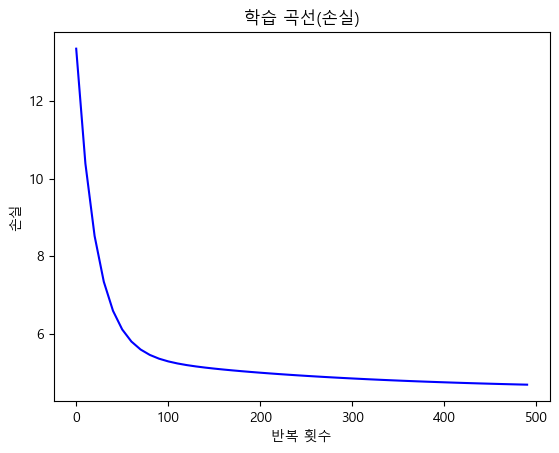

In [33]:
# 학습 곡선 출력(손실)

plt.plot(history[:,0], history[:,1], 'b')
plt.xlabel('반복 횟수')
plt.ylabel('손실')
plt.title('학습 곡선(손실)')
plt.show()

3.7의 결과와 비교해보면 동일한 것을 알 수 있다. 따라서, step 함수는 다음의 코드와 같은 로직을 수행하고 있다.
```
 with torch.no_grad():
        # 파라미터 수정
        # 프레임워크를 사용하는 경우는 step 함수가 이를 대신함
        W -= lr * W.grad
        B -= lr * B.grad
```

최적화 함수 튜닝

In [ ]:
# 초기화

# W와 B를 변수로 사용
W = torch.tensor(1.0, requires_grad=True).float()
B = torch.tensor(1.0, requires_grad=True).float()

# 반복 횟수
num_epochs = 500

# 학습률
lr = 0.001

# optimizer로 SGD(확률적 경사 하강법)을 사용
import torch.optim as optim
optimizer = optim.SGD([W, B], lr=lr, momentum=0.9) # momentum은 튜닝 기법 중 하나

# history 기록을 위한 배열 초기화
history2 = np.zeros((0, 2))

In [35]:
# 루프 처리

for epoch in range(num_epochs):

    # 예측 계산
    Yp = pred(X)
    
    # 손실 계산
    loss = mse(Yp, Y)

    # 경사 계산
    loss.backward()

    # 파라미터 수정
    optimizer.step()
    
    # 경삿값 초기화
    optimizer.zero_grad()
        
    # 손실 기록
    if (epoch %10 == 0):
        item = np.array([epoch, loss.item()])
        history2 = np.vstack((history2, item))
        print(f'epoch = {epoch}  loss = {loss:.4f}')

epoch = 0  loss = 13.3520
epoch = 10  loss = 5.7585
epoch = 20  loss = 5.9541
epoch = 30  loss = 5.0276
epoch = 40  loss = 4.8578
epoch = 50  loss = 4.7052
epoch = 60  loss = 4.6327
epoch = 70  loss = 4.5940
epoch = 80  loss = 4.5698
epoch = 90  loss = 4.5574
epoch = 100  loss = 4.5495
epoch = 110  loss = 4.5452
epoch = 120  loss = 4.5426
epoch = 130  loss = 4.5411
epoch = 140  loss = 4.5403
epoch = 150  loss = 4.5398
epoch = 160  loss = 4.5395
epoch = 170  loss = 4.5393
epoch = 180  loss = 4.5392
epoch = 190  loss = 4.5391
epoch = 200  loss = 4.5391
epoch = 210  loss = 4.5391
epoch = 220  loss = 4.5391
epoch = 230  loss = 4.5390
epoch = 240  loss = 4.5390
epoch = 250  loss = 4.5390
epoch = 260  loss = 4.5390
epoch = 270  loss = 4.5390
epoch = 280  loss = 4.5390
epoch = 290  loss = 4.5390
epoch = 300  loss = 4.5390
epoch = 310  loss = 4.5390
epoch = 320  loss = 4.5390
epoch = 330  loss = 4.5390
epoch = 340  loss = 4.5390
epoch = 350  loss = 4.5390
epoch = 360  loss = 4.5390
epoch = 370

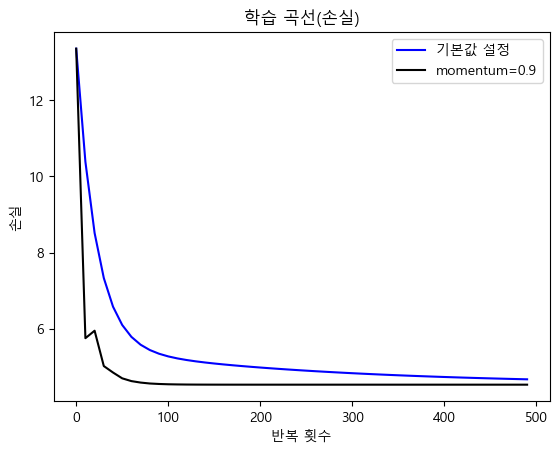

In [36]:
# 학습 곡선(손실) 출력

plt.plot(history[:,0], history[:,1], 'b', label='기본값 설정')
plt.plot(history2[:,0], history2[:,1], 'k', label='momentum=0.9')
plt.xlabel('반복 횟수')
plt.ylabel('손실')
plt.legend()
plt.title('학습 곡선(손실)')
plt.show()

 momentum 튜닝 기법을 사용하여, 학습속도가 빨라졌음을 확인할 수 있다.

#### 실습문제

위 예제에서, 
W와 B를 평균이 0이고 표준편차가 1인 정규분포에서 생성된 난수로 초기화를 하고, 
momentum 튜닝기법을 사용하여 학습을 수행하시오. 
하이퍼파라미터는 동일하게 사용하시오.